# Time Series Forecasting — Category Recap

> **Goal:** forecast future values of a series $\{y_t\}$ from past values (and possibly exogenous regressors).

This notebook ties together the three time-series notebooks.

| # | Algorithm | Family |
|---|---|---|
| 30 | ARIMA (AutoRegressive Integrated Moving Average) / SARIMA | Classical statistical |
| 31 | Prophet | Decomposable Bayesian |
| 32 | LSTM (Long Short-Term Memory) | Deep learning |

## Cheat-sheet — time series modelling landscape

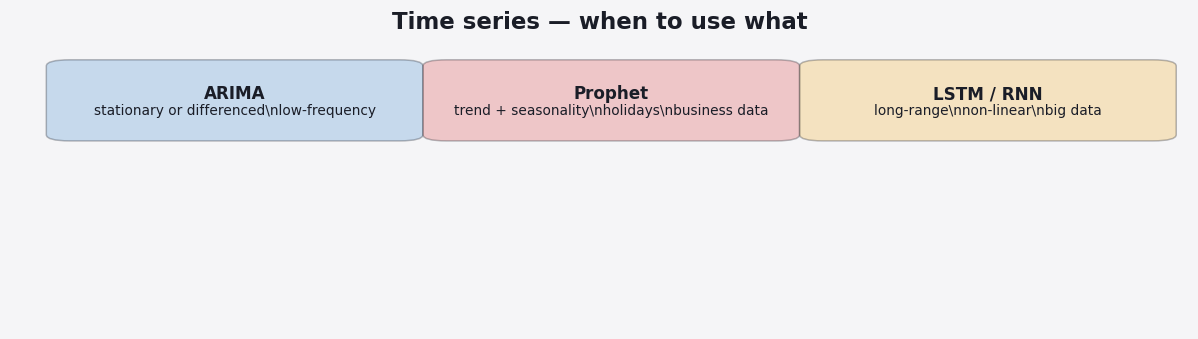

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis('off')
ax.text(0.5, 0.96, 'Time series — when to use what', ha='center', fontsize=15, weight='bold')
items = [('ARIMA', 'stationary or differenced\\nlow-frequency'), ('Prophet', 'trend + seasonality\\nholidays\\nbusiness data'), ('LSTM / RNN', 'long-range\\nnon-linear\\nbig data')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | Naive seasonal | ARIMA / SARIMA | Prophet | LSTM |
|---|---|---|---|---|
| Effort to fit | none | medium | low | high |
| Handles missing data | ❌ | ❌ | ✅ | partial |
| Multiple seasonalities | ❌ | partial | ✅ | partial |
| Exogenous regressors | ❌ | ✅ (SARIMAX) | ✅ | ✅ |
| Calibrated intervals | ❌ | ✅ | ✅ | ❌ |
| Many related series | ❌ | ❌ univariate | ❌ | ✅ |
| Long-range dependencies | ❌ | partial | partial | ✅ |
| Always benchmark against | — | naive | naive + ARIMA | naive + ARIMA + Prophet |

---
## Decision rule

In [ ]:
from IPython.display import SVG, display
_svg = """\
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 760 355" width="760" height="355"
     style="font-family:'DejaVu Sans',sans-serif;background:#f5f5f7;border-radius:8px;">
  <line x1="380" y1="57" x2="108" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="380" y1="57" x2="551" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="551" y1="142" x2="402" y2="185" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="551" y1="142" x2="627" y2="185" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="627" y1="227" x2="498" y2="270" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="627" y1="227" x2="683" y2="270" stroke="#c8ccd4" stroke-width="1.8"/>
  <text x="234" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="470" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <text x="465" y="160" text-anchor="end"   font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="594" y="160" text-anchor="start" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <text x="556" y="245" text-anchor="end"   font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="651" y="245" text-anchor="start" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <rect x="140" y="15" width="480" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="380" y="32" text-anchor="middle" font-size="12" fill="#1a1d27">Single short series,</text>
  <text x="380" y="48" text-anchor="middle" font-size="12" fill="#1a1d27">classical signal + noise?</text>
  <rect x="8" y="100" width="200" height="38" rx="6" fill="#7ecba1" fill-opacity="0.25" stroke="#7ecba1" stroke-width="1.5"/>
  <text x="108" y="124" text-anchor="middle" font-size="12" fill="#1a1d27">ARIMA / SARIMA</text>
  <rect x="381" y="100" width="340" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="551" y="117" text-anchor="middle" font-size="12" fill="#1a1d27">Business-style, multiple</text>
  <text x="551" y="133" text-anchor="middle" font-size="12" fill="#1a1d27">seasonalities &amp; holidays?</text>
  <rect x="320" y="185" width="165" height="38" rx="6" fill="#f4b942" fill-opacity="0.25" stroke="#f4b942" stroke-width="1.5"/>
  <text x="402" y="209" text-anchor="middle" font-size="12" fill="#1a1d27">Prophet</text>
  <rect x="500" y="185" width="254" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="627" y="201" text-anchor="middle" font-size="12" fill="#1a1d27">Many related series,</text>
  <text x="627" y="217" text-anchor="middle" font-size="12" fill="#1a1d27">long-range patterns?</text>
  <rect x="386" y="270" width="224" height="38" rx="6" fill="#56b6c2" fill-opacity="0.25" stroke="#56b6c2" stroke-width="1.5"/>
  <text x="498" y="285" text-anchor="middle" font-size="11" fill="#1a1d27">LSTM / Temporal</text>
  <text x="498" y="300" text-anchor="middle" font-size="11" fill="#1a1d27">Fusion Transformer</text>
  <rect x="610" y="270" width="146" height="38" rx="6" fill="#888fa5" fill-opacity="0.25" stroke="#888fa5" stroke-width="1.5"/>
  <text x="683" y="285" text-anchor="middle" font-size="11" fill="#1a1d27">Revisit</text>
  <text x="683" y="300" text-anchor="middle" font-size="11" fill="#1a1d27">simpler models</text>
</svg>"""
display(SVG(_svg))

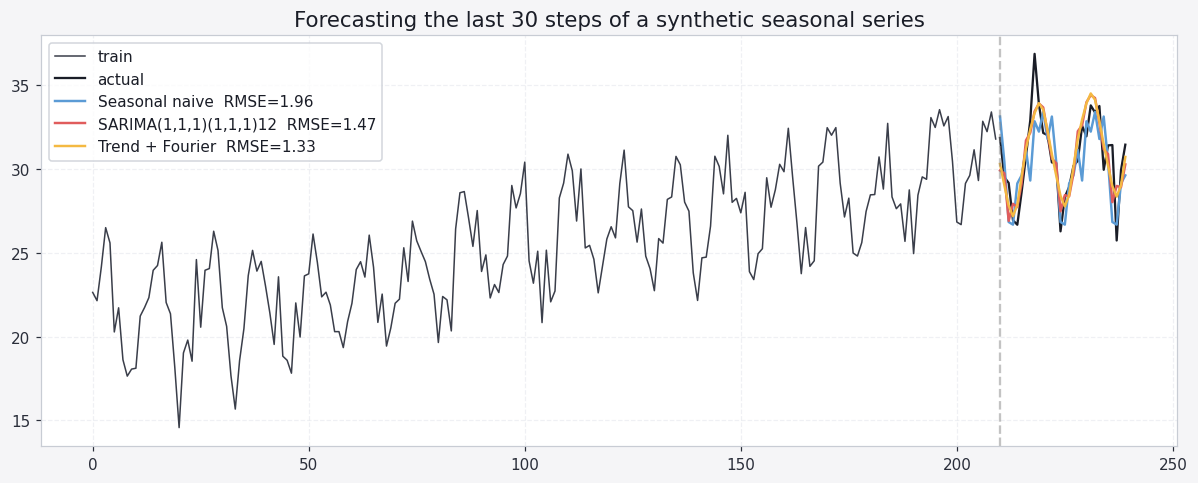

In [3]:
# Build a synthetic series with trend + weekly seasonality + noise; forecast the last 30 steps.
import pandas as pd

rng = np.random.RandomState(0)
n = 240
t = np.arange(n)
trend  = 0.05 * t
season = 3 * np.sin(2*np.pi*t/12)
y = 20 + trend + season + 1.5*rng.randn(n)

H = 30
y_tr, y_te = y[:-H], y[-H:]
fc = {}

# 1) Seasonal naive: repeat the last full season
fc['Seasonal naive'] = np.tile(y_tr[-12:], int(np.ceil(H/12)))[:H]

# 2) ARIMA via statsmodels
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    mod = SARIMAX(y_tr, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
    fc['SARIMA(1,1,1)(1,1,1)12'] = mod.forecast(H)
except Exception as e:
    print('SARIMA skipped:', e)

# 3) Linear-trend + Fourier (Prophet-flavoured) baseline
def fourier_features(t, period, K):
    return np.column_stack([np.sin(2*np.pi*k*t/period) for k in range(1,K+1)] +
                           [np.cos(2*np.pi*k*t/period) for k in range(1,K+1)])

K = 3
F_tr = fourier_features(np.arange(len(y_tr)), 12, K)
X_tr = np.column_stack([np.arange(len(y_tr)), F_tr])
X_te = np.column_stack([np.arange(len(y_tr), len(y_tr)+H), fourier_features(np.arange(len(y_tr), len(y_tr)+H), 12, K)])
beta, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(X_tr)), X_tr]), y_tr, rcond=None)
fc['Trend + Fourier'] = (np.column_stack([np.ones(H), X_te]) @ beta)

from sklearn.metrics import mean_absolute_error
rmse = lambda a, b: np.sqrt(np.mean((a-b)**2))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t[:-H], y_tr, color='#3a3e4a', lw=1.0, label='train')
ax.plot(t[-H:], y_te, color='#1a1d27', lw=1.5, label='actual')
for i, (name, yp) in enumerate(fc.items()):
    ax.plot(t[-H:], yp, color=PALETTE[i], lw=1.6, label=f'{name}  RMSE={rmse(y_te, yp):.2f}')
ax.axvline(t[-H], color='#888', ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=10)
ax.set_title('Forecasting the last 30 steps of a synthetic seasonal series')
ax.grid(True)
plt.tight_layout()
plt.show()


---
## What we just saw

- **Seasonal naive** is a serious baseline — beating it is the bar every fancy model must clear.
- **SARIMA** captures both the trend and the periodic component if available.
- **Trend + Fourier** is essentially Prophet's trick stripped down — it fits the same shape with linear regression.

> The LSTM is omitted from this benchmark because a single short series does not have the volume it needs.

> Lesson: **always benchmark against the seasonal naive forecast.** Many "production" models in industry quietly fail to beat it.